# 2.3 Complex Machine Learning Models and Keras Part 2 - 1. Basel Results (ALL years)

## 01 Load Libraries & Dataset
## 02 Clean & Wrangle
## 03 Shaping Data
## 04 Spliting Data
## 05 Training a Random Forest Classifier
## 06 Feature Importance Analysis
## 07 Insights

### 01 Load Libraries & Dataset

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score

In [5]:
# Create a path for the import of dataset

path = r'C:\Users\wallm\02 2025 Machine Learning Project\02 Data'

In [7]:
# Import weather dataset

climate = pd.read_csv(os.path.join(path, '02 Prepared Data', 'Dataset-weather-cleaned-reshaped.csv'))

In [9]:
climate.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,KASSEL_cloud_cover,STOCKHOLM_humidity,MUNCHENB_pressure
0,19600101,-1.6,0.661,0.826,-0.002,-1.101,-0.265,-0.903,-0.529,-0.846,...,-1.300,-0.806,-0.088,0.372,-0.668,-0.520,-0.752,0.714,1.544,0.095
1,19600102,-1.6,0.245,0.736,-0.002,-1.058,1.659,-0.810,-0.583,-0.462,...,-1.262,-1.042,0.503,-0.829,-0.548,-0.629,-0.407,1.176,-0.712,0.067
2,19600103,-1.6,1.076,1.278,-0.002,-1.251,0.156,-1.065,-0.257,-0.187,...,-0.433,-1.136,-0.396,-1.010,-0.067,0.054,-0.177,0.252,-0.274,0.132
3,19600104,-1.6,-1.002,1.458,-0.002,-0.822,-0.446,-0.114,-0.556,-0.386,...,0.388,-1.183,0.669,-1.040,-0.999,-0.164,-0.839,1.176,1.544,0.419
4,19600105,-1.6,0.245,1.729,-0.002,-0.747,-0.165,0.187,-1.004,-1.076,...,1.730,-0.795,-0.491,0.673,-1.509,-1.340,-1.471,0.252,1.419,0.388


In [11]:
climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22950 entries, 0 to 22949
Columns: 137 entries, DATE to MUNCHENB_pressure
dtypes: float64(136), int64(1)
memory usage: 24.0 MB


In [13]:
climate.shape

(22950, 137)

In [15]:
# Import the 'Pleasant weather' dataset

pleasantweather = pd.read_csv(os.path.join(path, '01 Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [17]:
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
pleasantweather.shape

(22950, 16)

### 02 Clean & Wrangle

In [21]:
climate.isnull().sum()

DATE                  0
MONTH                 0
BASEL_cloud_cover     0
BASEL_humidity        0
BASEL_pressure        0
                     ..
VALENTIA_temp_min     0
VALENTIA_temp_max     0
KASSEL_cloud_cover    0
STOCKHOLM_humidity    0
MUNCHENB_pressure     0
Length: 137, dtype: int64

In [23]:
pleasantweather.isnull().sum()

DATE                           0
BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [31]:
# Filter for columns related to 'BASEL' station
basel_station = [x for x in climate.columns if 'BASEL' in x.upper()]

# Create a new DataFrame for Basel station data
basel_df = climate[basel_station]

basel_df

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max
0,0.661,0.826,-0.002,-1.101,-0.265,-0.903,-0.529,-0.846,-0.478
1,0.245,0.736,-0.002,-1.058,1.659,-0.810,-0.583,-0.462,-0.570
2,1.076,1.278,-0.002,-1.251,0.156,-1.065,-0.257,-0.187,-0.593
3,-1.002,1.458,-0.002,-0.822,-0.446,-0.114,-0.556,-0.386,-0.513
4,0.245,1.729,-0.002,-0.747,-0.165,0.187,-1.004,-1.076,-1.040
...,...,...,...,...,...,...,...,...,...
22945,-1.833,0.284,1.037,-0.006,-0.005,0.721,0.748,0.779,0.724
22946,0.245,0.103,0.976,-0.006,-0.005,0.187,0.857,1.224,0.782
22947,-0.586,0.013,0.716,-0.006,-0.005,0.350,0.857,1.040,0.839
22948,-0.171,0.374,0.487,-0.006,-0.005,0.280,0.680,0.810,0.690


In [33]:
# Reduce pleasantweather dataset to Basel's data only

pleasantweather_basel = pleasantweather['BASEL_pleasant_weather']

pleasantweather_basel

0        0
1        0
2        0
3        0
4        0
        ..
22945    0
22946    0
22947    0
22948    0
22949    0
Name: BASEL_pleasant_weather, Length: 22950, dtype: int64

In [35]:
#Check the shape

basel_df.shape 

(22950, 9)

In [37]:
#Check the shape

pleasantweather_basel.shape

(22950,)

### 03 Shaping Data

In [39]:
# Define features and target for Basel

X_basel = basel_df  # Basel weather features
y_basel = pleasantweather['BASEL_pleasant_weather']  # Basel target labels

# Convert to NumPy arrays

X = np.array(X_basel)
y = np.array(y_basel) # as previously described - these tools expect the data to be in a clean, fast format - "NumPy arrays".

In [41]:
X.shape

(22950, 9)

In [43]:
y.shape

(22950,)

##### Now the data is in the perfect format to be used in a machine learning model!

##### Next Step:
##### - Train a Random Forest model to learn from this data
##### - Plot one or two of the trees to visually explain decisions
##### - Identify which weather features or stations are most influential

### 04 Spliting Data

In [45]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [47]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


### 05 Training a Random Forest Classifier

In [49]:
# Initialize the Random Forest model
# This creates 100 decision trees and uses them together to make predictions
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training set
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Check how accurate the model is
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy on Test Set:", round(accuracy * 100, 2), "%")

Random Forest Accuracy on Test Set: 100.0 %


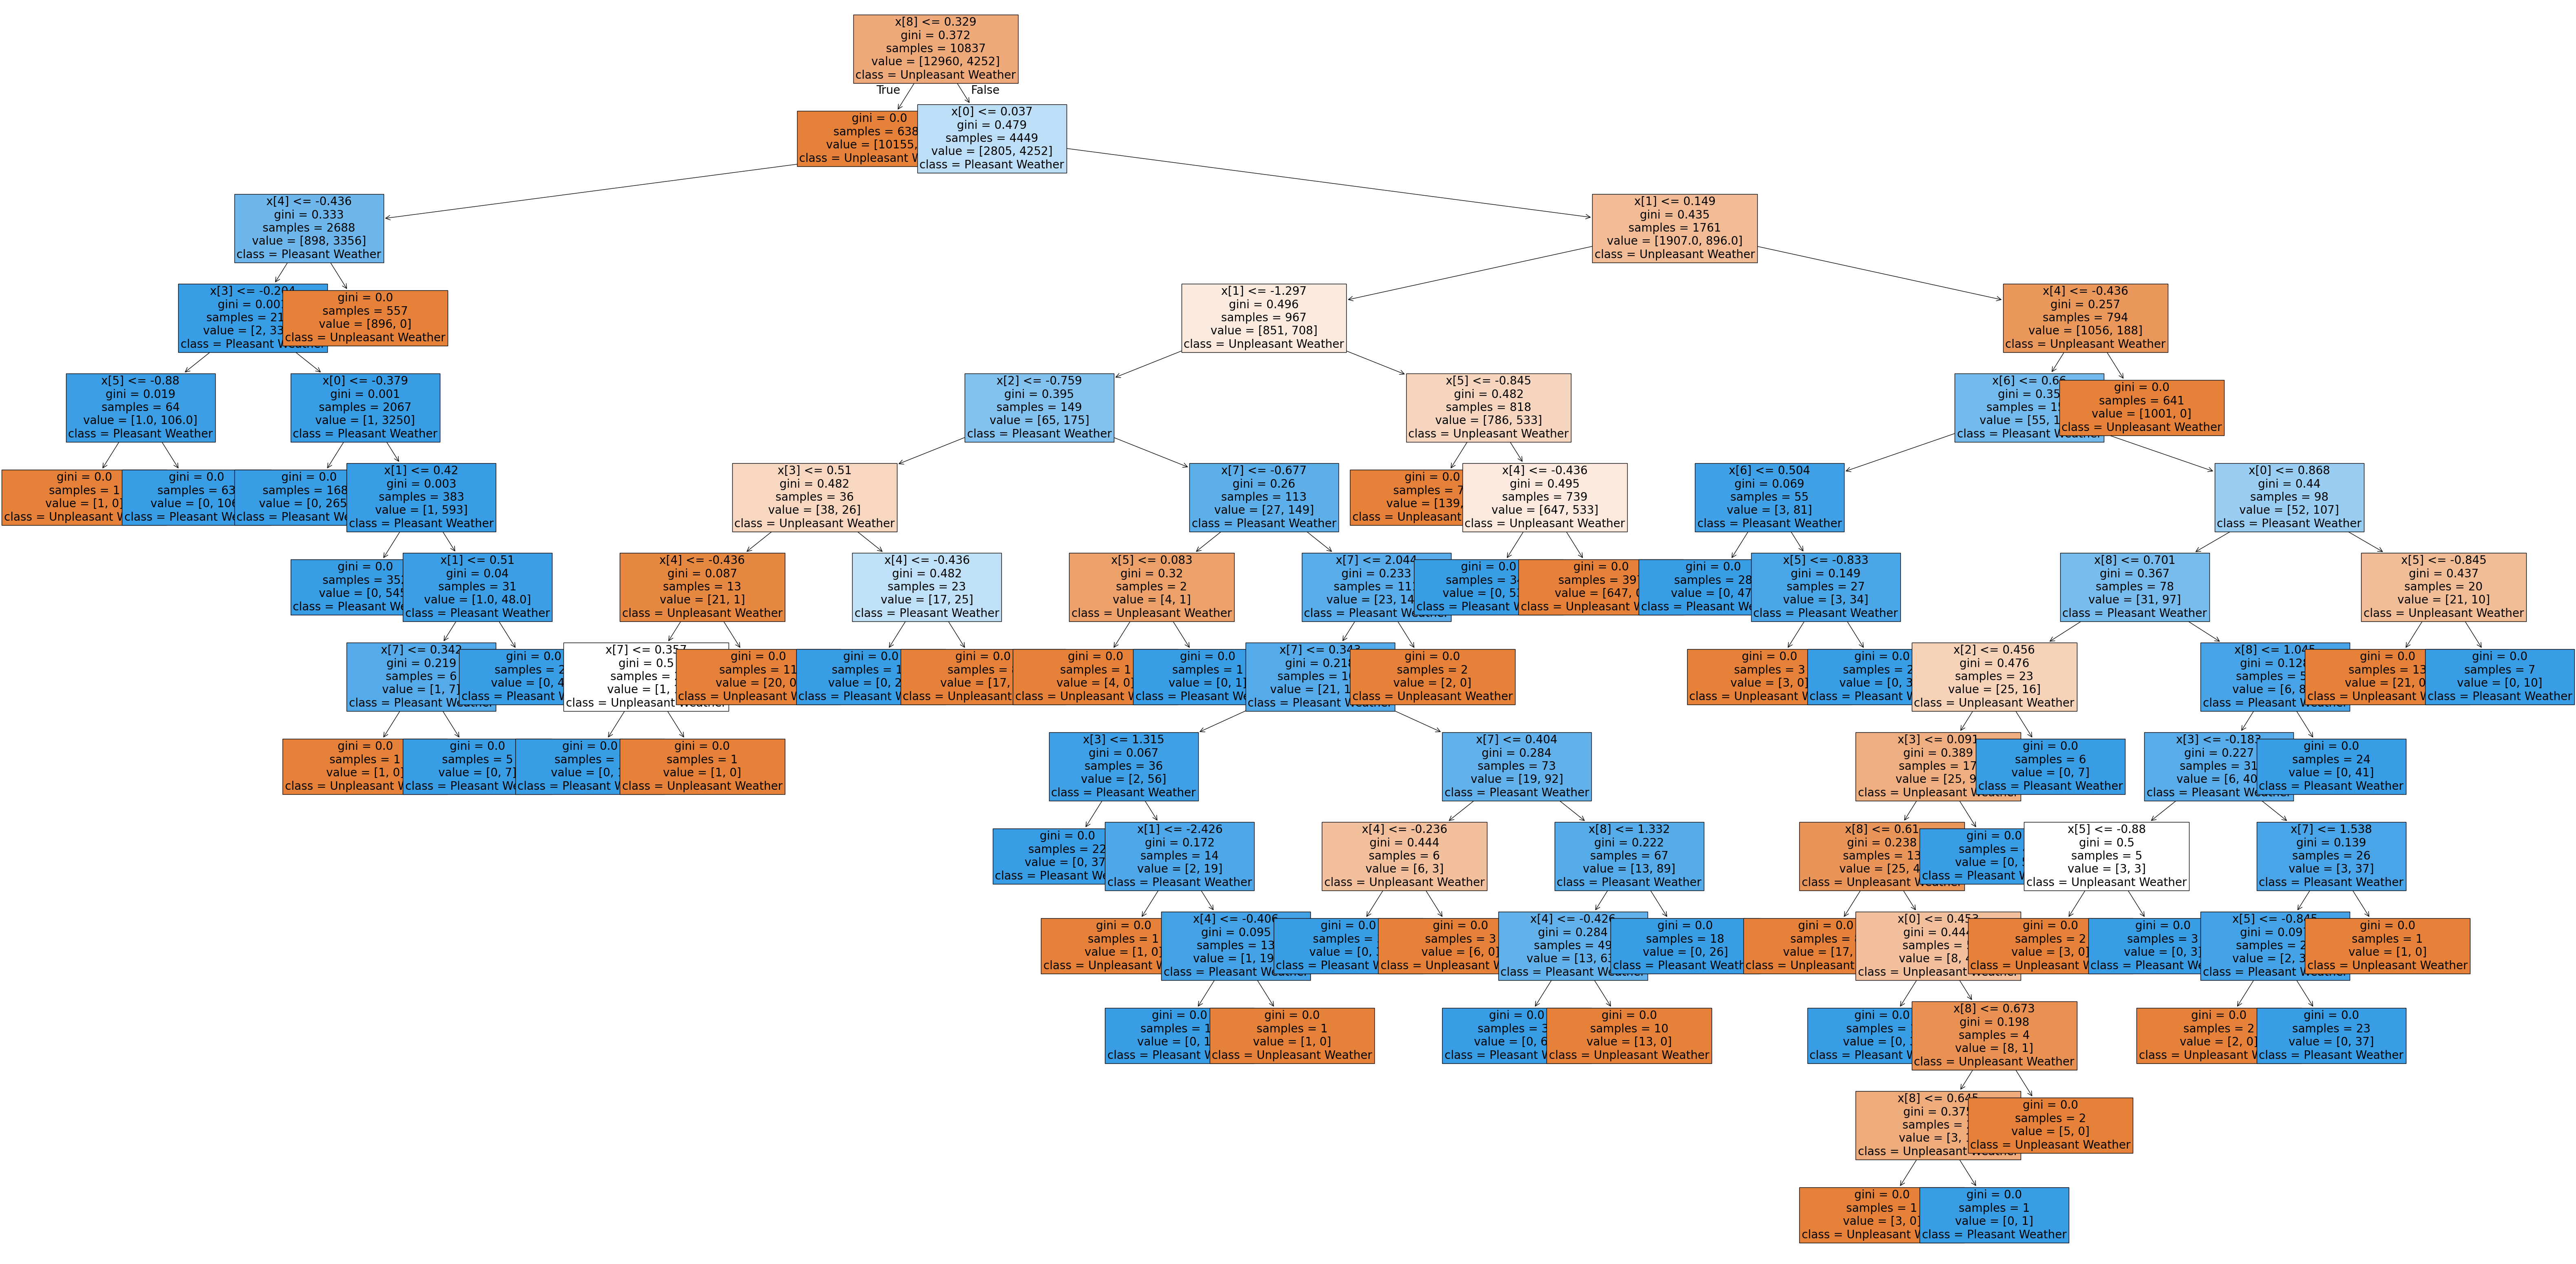

In [51]:
# Define class names for readability
class_names = ['Unpleasant Weather', 'Pleasant Weather']

# Plot the tree
fig = plt.figure(figsize=(80, 40))
plot_tree(clf.estimators_[15], 
          filled=True, 
          fontsize=20,
          feature_names=None,  # You can add your feature names here if you'd like
          class_names=class_names);  # Adds class labels at the leaves

### 06 Feature Importance Analysis

In [53]:
# Retrieve feature importances from the trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape) # Should print: (9,)
newarray # This shows the raw importance values

(9,)


array([0.02612365, 0.01131743, 0.00667535, 0.10666495, 0.34058348,
       0.12129856, 0.08800662, 0.03324133, 0.26608864])

In [59]:
# Clean feature names from BASEL columns

basel_features = [feature.replace('BASEL_', '') for feature in basel_station]
basel_features

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [61]:
# Create Series for feature importance

important = pd.Series(newarray, index=basel_features).sort_values(ascending=False)
important

precipitation       0.340583
temp_max            0.266089
sunshine            0.121299
global_radiation    0.106665
temp_mean           0.088007
temp_min            0.033241
cloud_cover         0.026124
humidity            0.011317
pressure            0.006675
dtype: float64

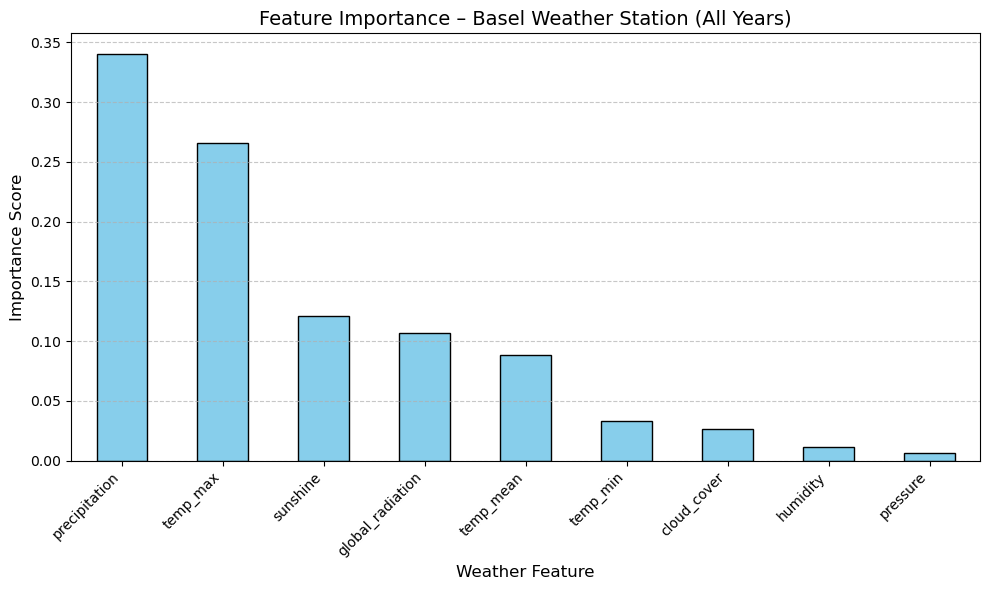

In [63]:
# Plot feature importance

plt.figure(figsize=(10, 6))
important.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Importance – Basel Weather Station (All Years)', fontsize=14)
plt.xlabel('Weather Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 07 Insights

The Random Forest model trained on Basel’s weather data achieved **100% accuracy** in predicting whether a day was pleasant or not.
- **Precipitation** was the strongest predictor — less rain or snow typically meant a more pleasant day.
- **Maximum temperature (temp_max)** also had a major impact — warmer highs correlated with pleasant days.
- **Sunshine** and **global radiation** (solar energy) were also highly influential.

In contrast, variables like **humidity**, **air pressure**, and **cloud cover** had relatively minor influence.